# LIN28A project upgrade v3: 재현 가능한 direct target 분석

## 자율주제

**LIN28A에 강하게 결합한 mRNA가 Lin28a knockdown 후 ribosome density 증가를 보이는지 확인하고, ER/membrane/secretory pathway 관련 후보 direct target을 우선순위화한다.**

## 이전 과제 대비 upgrade 포인트

1. `read-counts.txt`가 있으면 사용하고, 없으면 datapack BAM과 GTF에서 `featureCounts`로 다시 생성합니다.
2. raw count 비율이 아니라 library size 차이를 보정한 **CPM normalization**을 적용합니다.
3. CLIP antibody replicate가 여러 개 있을 경우 자동 탐지해서 median CLIP enrichment를 계산합니다.
4. Spearman correlation, bootstrap 95% CI, Mann-Whitney U test, permutation test를 함께 수행합니다.
5. 논문 Figure 4D/4E 스타일 분석에 더해, ER/membrane/secretory annotation 기반 후보 direct target ranking table을 만듭니다.
6. 2주차 RPF start-codon profile과 3주차 let-7 entropy 분석을 선택적으로 다시 실행해, 기존 과제와 연결되는 업그레이드 결과를 남깁니다.

> 제출 전에는 반드시 **Runtime → Run all**을 실행한 뒤, 마지막 checklist cell이 `PASS`인지 확인하고 저장한 다음 GitHub에 push하세요.


## 0. Google Drive 연결 및 경로 설정

Colab에서 실행하면 Google Drive를 연결합니다. 로컬/Jupyter 서버에서 실행하면 현재 폴더 기준으로 진행합니다.


In [1]:
from pathlib import Path
import os, sys, subprocess, shutil, gzip, re, math, json, random, time

try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception as e:
    print('Colab이 아니거나 Drive 연결이 필요 없는 환경입니다:', e)
    IN_COLAB = False

# 프로젝트 결과를 저장할 폴더입니다.
PROJECT_DIR_CANDIDATES = []
if IN_COLAB:
    PROJECT_DIR_CANDIDATES.append(Path('/content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3'))
PROJECT_DIR_CANDIDATES.append(Path.cwd() / 'LIN28A_upgrade_v3')

PROJECT_DIR = PROJECT_DIR_CANDIDATES[0]
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
FIGDIR = PROJECT_DIR / 'figures'
RESULTDIR = PROJECT_DIR / 'results'
TMPDIR = PROJECT_DIR / 'tmp'
for p in [FIGDIR, RESULTDIR, TMPDIR]:
    p.mkdir(parents=True, exist_ok=True)

print('PROJECT_DIR =', PROJECT_DIR)
print('FIGDIR      =', FIGDIR)
print('RESULTDIR   =', RESULTDIR)


Mounted at /content/drive
PROJECT_DIR = /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3
FIGDIR      = /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/figures
RESULTDIR   = /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/results


## 1. 필요한 패키지와 외부 프로그램 확인

- Python 패키지: `pandas`, `numpy`, `matplotlib`, `scipy`
- 선택적 외부 프로그램: `featureCounts`, `samtools`, `bedtools`

외부 프로그램은 `read-counts.txt`를 새로 만들거나 BAM 수준 분석을 할 때 필요합니다. 이미 `read-counts.txt`가 있으면 핵심 분석은 Python만으로 실행됩니다.


In [2]:
def pip_install_if_missing(pkg_name, import_name=None):
    import importlib.util
    import_name = import_name or pkg_name
    if importlib.util.find_spec(import_name) is None:
        print(f'Installing {pkg_name} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg_name])

for pkg, imp in [('pandas','pandas'), ('numpy','numpy'), ('matplotlib','matplotlib'), ('scipy','scipy')]:
    pip_install_if_missing(pkg, imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, mannwhitneyu, fisher_exact

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

def which(cmd):
    return shutil.which(cmd)

print('Python OK')
print('featureCounts:', which('featureCounts'))
print('samtools     :', which('samtools'))
print('bedtools     :', which('bedtools'))


Python OK
featureCounts: None
samtools     : None
bedtools     : None


## 2. datapack, GTF, read-counts.txt 찾기

이 셀은 다음을 자동으로 찾습니다.

- `CLIP-35L33G.bam`, `RPF-siLuc.bam` 등이 들어 있는 `binfo1-datapack1` 폴더
- `gencode.gtf` 또는 `gencode.gtf.gz`
- 이전 과제에서 만든 `read-counts.txt`

`read-counts.txt`가 없으면 다음 셀에서 자동 생성합니다.


In [3]:
BAM_BASENAMES = [
    'CLIP-35L33G.bam', 'CLIP-2J3.bam', 'CLIP-Abcam.bam',
    'RNA-control.bam', 'RNA-siLin28a.bam', 'RNA-siLuc.bam',
    'RPF-siLin28a.bam', 'RPF-siLuc.bam'
]

search_roots = [Path.cwd(), PROJECT_DIR, PROJECT_DIR.parent]
if IN_COLAB:
    search_roots += [Path('/content/drive/MyDrive/binfo1-datapack1'), Path('/content/drive/MyDrive/binfo1-work'), Path('/content/drive/MyDrive')]
search_roots += [Path('../binfo1-datapack1'), Path('../binfo1-work')]

# 중복 제거
unique_roots = []
for p in search_roots:
    try:
        p = p.resolve()
    except Exception:
        pass
    if p not in unique_roots:
        unique_roots.append(p)
search_roots = unique_roots


def find_file(filename, roots):
    for root in roots:
        if not root.exists():
            continue
        direct = root / filename
        if direct.exists():
            return direct
        # 너무 큰 전체 Drive scan을 피하기 위해 흔한 폴더 1단계만 검색
        for child in list(root.glob('*'))[:200]:
            if child.is_dir() and (child / filename).exists():
                return child / filename
    return None

bam_paths = {name: find_file(name, search_roots) for name in BAM_BASENAMES}
found_bams = {k:v for k,v in bam_paths.items() if v is not None}
print('Found BAM files:')
for k,v in found_bams.items():
    print(' ', k, '->', v)

DATAPACK_DIR = None
if found_bams:
    DATAPACK_DIR = next(iter(found_bams.values())).parent
else:
    DATAPACK_DIR = PROJECT_DIR / 'binfo1-datapack1'
    DATAPACK_DIR.mkdir(exist_ok=True)
print('DATAPACK_DIR =', DATAPACK_DIR)

GTF_PATH = find_file('gencode.gtf', search_roots) or find_file('gencode.gtf.gz', search_roots)
READ_COUNTS_PATH = find_file('read-counts.txt', [PROJECT_DIR, PROJECT_DIR.parent, Path.cwd()])
if READ_COUNTS_PATH is None and IN_COLAB:
    READ_COUNTS_PATH = find_file('read-counts.txt', [Path('/content/drive/MyDrive/binfo1-work'), Path('/content/drive/MyDrive')])

print('GTF_PATH         =', GTF_PATH)
print('READ_COUNTS_PATH =', READ_COUNTS_PATH)


Found BAM files:
  CLIP-35L33G.bam -> /content/drive/MyDrive/binfo1-work/CLIP-35L33G.bam
  RNA-control.bam -> /content/drive/MyDrive/binfo1-work/RNA-control.bam
  RNA-siLin28a.bam -> /content/drive/MyDrive/binfo1-work/RNA-siLin28a.bam
  RNA-siLuc.bam -> /content/drive/MyDrive/binfo1-work/RNA-siLuc.bam
  RPF-siLin28a.bam -> /content/drive/MyDrive/binfo1-work/RPF-siLin28a.bam
  RPF-siLuc.bam -> /content/drive/MyDrive/binfo1-work/RPF-siLuc.bam
DATAPACK_DIR = /content/drive/MyDrive/binfo1-work
GTF_PATH         = /content/drive/MyDrive/binfo1-work/gencode.gtf
READ_COUNTS_PATH = /content/drive/MyDrive/binfo1-work/read-counts.txt


## 3. 필요한 데이터가 없을 때 다운로드/설치/카운트 생성

핵심 분석은 `read-counts.txt`만 있으면 됩니다. 이 파일이 없으면 다음 순서로 복구합니다.

1. datapack BAM 파일이 없으면 course datapack URL에서 다운로드를 시도합니다.
2. GTF가 없으면 GENCODE mouse annotation을 다운로드합니다.
3. `featureCounts`가 없으면 `apt-get` 또는 `conda/mamba`로 설치를 시도합니다.
4. BAM 파일과 GTF로 `read-counts.txt`를 생성합니다.

실패하면 아래 출력 메시지를 보고, 이전 과제의 `read-counts.txt`를 `PROJECT_DIR` 또는 `binfo1-work`에 복사한 뒤 다시 실행하세요.


In [4]:
def run(cmd, cwd=None, check=True):
    print('\n$ ' + cmd)
    return subprocess.run(cmd, shell=True, cwd=cwd, check=check, text=True)

# 3-1. BAM이 하나도 없으면 datapack 다운로드 시도
if not found_bams:
    if IN_COLAB:
        datapack_parent = Path('/content/drive/MyDrive')
    else:
        datapack_parent = PROJECT_DIR
    print('BAM 파일을 찾지 못했습니다. datapack 다운로드를 시도합니다.')
    run(f'wget -O - --no-check-certificate https://hyeshik.qbio.io/binfo/binfo1-datapack1.tar | tar -C {datapack_parent} -xf -', check=False)
    # 다시 검색
    search_roots.append(datapack_parent / 'binfo1-datapack1')
    bam_paths = {name: find_file(name, search_roots) for name in BAM_BASENAMES}
    found_bams = {k:v for k,v in bam_paths.items() if v is not None}
    DATAPACK_DIR = next(iter(found_bams.values())).parent if found_bams else DATAPACK_DIR

# 3-2. GTF 다운로드
if GTF_PATH is None:
    target = DATAPACK_DIR / 'gencode.gtf.gz'
    print('GTF 파일을 찾지 못했습니다. GENCODE annotation 다운로드를 시도합니다:', target)
    run(f'wget --no-check-certificate -O {target} http://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_mouse/release_M27/gencode.vM27.annotation.gtf.gz', check=False)
    GTF_PATH = target if target.exists() and target.stat().st_size > 1000 else None

# 3-3. featureCounts 설치 시도
if READ_COUNTS_PATH is None:
    if which('featureCounts') is None:
        print('featureCounts가 없어 설치를 시도합니다.')
        if IN_COLAB or which('apt-get') is not None:
            run('apt-get update -qq && apt-get install -y -qq subread samtools bedtools', check=False)
        if which('featureCounts') is None and which('conda') is not None:
            run('conda install -y -c bioconda subread samtools bedtools', check=False)
        if which('featureCounts') is None and which('mamba') is not None:
            run('mamba install -y -c bioconda subread samtools bedtools', check=False)

# 3-4. read-counts 생성
if READ_COUNTS_PATH is None:
    if GTF_PATH is None:
        raise FileNotFoundError('GTF 파일을 찾거나 다운로드하지 못했습니다. gencode.gtf.gz를 datapack 폴더에 넣고 다시 실행하세요.')
    available_bams = [str(p) for p in bam_paths.values() if p is not None and Path(p).exists()]
    if len(available_bams) < 5:
        raise FileNotFoundError('BAM 파일을 충분히 찾지 못했습니다. binfo1-datapack1 폴더가 Google Drive에 있는지 확인하세요.')
    if which('featureCounts') is None:
        raise RuntimeError('featureCounts 설치에 실패했습니다. 이전 과제에서 만든 read-counts.txt를 PROJECT_DIR에 복사한 뒤 다시 실행하세요.')
    READ_COUNTS_PATH = PROJECT_DIR / 'read-counts.txt'
    bam_string = ' '.join(available_bams)
    run(f'featureCounts -T 2 -a {GTF_PATH} -o {READ_COUNTS_PATH} {bam_string}', check=True)

print('\n최종 데이터 경로')
print('DATAPACK_DIR      =', DATAPACK_DIR)
print('GTF_PATH          =', GTF_PATH)
print('READ_COUNTS_PATH  =', READ_COUNTS_PATH)



최종 데이터 경로
DATAPACK_DIR      = /content/drive/MyDrive/binfo1-work
GTF_PATH          = /content/drive/MyDrive/binfo1-work/gencode.gtf
READ_COUNTS_PATH  = /content/drive/MyDrive/binfo1-work/read-counts.txt


## 4. `read-counts.txt` 로드 및 column 자동 인식

`featureCounts` 결과는 BAM 파일이 전체 경로로 표시될 수 있으므로 column 이름을 basename으로 정리합니다.


In [5]:
def normalize_count_columns(df):
    rename = {}
    for c in df.columns:
        s = str(c)
        base = Path(s).name
        rename[c] = base
    return df.rename(columns=rename)

def load_featurecounts(path):
    df = pd.read_csv(path, sep='\t', comment='#')
    if 'Geneid' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Geneid'})
    df = normalize_count_columns(df)
    return df

cnts = load_featurecounts(READ_COUNTS_PATH)
print('count table shape:', cnts.shape)
display(cnts.head())
print('columns:', list(cnts.columns))

# 필요한 column 찾기
all_cols = list(cnts.columns)
meta_cols = [c for c in ['Geneid','Chr','Start','End','Strand','Length'] if c in cnts.columns]


def pick_col(patterns, required=True):
    patterns = [p.lower() for p in patterns]
    matches = []
    for c in all_cols:
        low = str(c).lower()
        if all(p in low for p in patterns):
            matches.append(c)
    if required and not matches:
        raise ValueError(f'필수 column을 찾지 못했습니다: {patterns}\n현재 columns: {all_cols}')
    return matches[0] if matches else None

clip_cols = [c for c in all_cols if 'clip' in str(c).lower() and str(c).lower().endswith('.bam')]
if not clip_cols:
    clip_cols = [c for c in all_cols if 'clip' in str(c).lower()]

rna_control_col = pick_col(['rna-control'])
rna_siluc_col   = pick_col(['rna-siluc'])
rna_silin_col   = pick_col(['rna-silin28a'])
rpf_siluc_col   = pick_col(['rpf-siluc'])
rpf_silin_col   = pick_col(['rpf-silin28a'])

needed = clip_cols + [rna_control_col, rna_siluc_col, rna_silin_col, rpf_siluc_col, rpf_silin_col]
print('CLIP columns:', clip_cols)
print('RNA control :', rna_control_col)
print('RNA siLuc   :', rna_siluc_col)
print('RNA siLin28a:', rna_silin_col)
print('RPF siLuc   :', rpf_siluc_col)
print('RPF siLin28a:', rpf_silin_col)


count table shape: (55359, 12)


,Geneid,Chr,Start,End,Strand,Length,CLIP-35L33G.bam,RNA-control.bam,RNA-siLin28a.bam,RNA-siLuc.bam,RPF-siLin28a.bam,RPF-siLuc.bam
0,ENSMUSG00000102693.2,chr1,3143476,3144545,+,1070,0,0,0,0,0,0
1,ENSMUSG00000064842.3,chr1,3172239,3172348,+,110,0,0,0,0,0,0
2,ENSMUSG00000051951.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,4,1,1,1,0,0
3,ENSMUSG00000102851.2,chr1,3322980,3323459,+,480,3,0,0,0,0,0
4,ENSMUSG00000103377.2,chr1,3435954,3438772,-,2819,0,0,0,0,0,0


columns: ['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length', 'CLIP-35L33G.bam', 'RNA-control.bam', 'RNA-siLin28a.bam', 'RNA-siLuc.bam', 'RPF-siLin28a.bam', 'RPF-siLuc.bam']
CLIP columns: ['CLIP-35L33G.bam']
RNA control : RNA-control.bam
RNA siLuc   : RNA-siLuc.bam
RNA siLin28a: RNA-siLin28a.bam
RPF siLuc   : RPF-siLuc.bam
RPF siLin28a: RPF-siLin28a.bam


## 5. CPM normalization 및 핵심 지표 계산

계산식은 다음과 같습니다.

- `clip_log2` = median log2((CLIP CPM + pseudocount) / (RNA-control CPM + pseudocount))
- `rden_log2` = log2((RPF-siLin28a CPM / RNA-siLin28a CPM) / (RPF-siLuc CPM / RNA-siLuc CPM))
- `rna_change_log2` = log2(RNA-siLin28a CPM / RNA-siLuc CPM)

즉, `rden_log2 > 0`이면 Lin28a knockdown 후 ribosome density가 증가한 유전자입니다.


In [6]:
count_cols = list(dict.fromkeys(needed))
for c in count_cols + (['Length'] if 'Length' in cnts.columns else []):
    cnts[c] = pd.to_numeric(cnts[c], errors='coerce').fillna(0)

lib_sizes = cnts[count_cols].sum(axis=0)
cpm = cnts[count_cols].divide(lib_sizes, axis=1) * 1_000_000
cpm.columns = [c + '.CPM' for c in cpm.columns]

analysis = cnts[meta_cols].copy()
analysis = pd.concat([analysis, cnts[count_cols], cpm], axis=1)

PC = 0.1
rna_control_cpm = rna_control_col + '.CPM'
rna_siluc_cpm = rna_siluc_col + '.CPM'
rna_silin_cpm = rna_silin_col + '.CPM'
rpf_siluc_cpm = rpf_siluc_col + '.CPM'
rpf_silin_cpm = rpf_silin_col + '.CPM'

clip_log2_cols = []
for c in clip_cols:
    col = 'clip_log2_' + c.replace('.bam','').replace('-','_')
    analysis[col] = np.log2((analysis[c + '.CPM'] + PC) / (analysis[rna_control_cpm] + PC))
    clip_log2_cols.append(col)

analysis['clip_log2'] = analysis[clip_log2_cols].median(axis=1)
analysis['rden_log2'] = np.log2((analysis[rpf_silin_cpm] + PC) / (analysis[rna_silin_cpm] + PC)) - np.log2((analysis[rpf_siluc_cpm] + PC) / (analysis[rna_siluc_cpm] + PC))
analysis['rna_change_log2'] = np.log2((analysis[rna_silin_cpm] + PC) / (analysis[rna_siluc_cpm] + PC))
analysis['mean_rna_cpm'] = analysis[[rna_control_cpm, rna_siluc_cpm, rna_silin_cpm]].mean(axis=1)
analysis['mean_rpf_cpm'] = analysis[[rpf_siluc_cpm, rpf_silin_cpm]].mean(axis=1)

# Geneid version 제거
analysis['gene_id_short'] = analysis['Geneid'].astype(str).str.replace(r'\.\d+$', '', regex=True)

# low count filter: RNA와 RPF가 너무 낮은 유전자는 제외
keep = (analysis['mean_rna_cpm'] >= 0.5) & (analysis['mean_rpf_cpm'] >= 0.05)
analysis_f = analysis.loc[keep].copy()
print('전체 유전자 수:', len(analysis))
print('분석에 사용한 유전자 수:', len(analysis_f))
print('library sizes:')
display(lib_sizes.to_frame('library_size'))
display(analysis_f[['Geneid','clip_log2','rden_log2','rna_change_log2','mean_rna_cpm','mean_rpf_cpm']].head())

analysis.to_csv(RESULTDIR / 'lin28a_all_genes_metrics.csv', index=False)
analysis_f.to_csv(RESULTDIR / 'lin28a_filtered_gene_metrics.csv', index=False)
print('saved:', RESULTDIR / 'lin28a_filtered_gene_metrics.csv')


전체 유전자 수: 55359
분석에 사용한 유전자 수: 17314
library sizes:


,library_size
CLIP-35L33G.bam,13630945
RNA-control.bam,5200836
RNA-siLuc.bam,9748787
RNA-siLin28a.bam,12338280
RPF-siLuc.bam,12932285
RPF-siLin28a.bam,10694162


,Geneid,clip_log2,rden_log2,rna_change_log2,mean_rna_cpm,mean_rpf_cpm
15,ENSMUSG00000102343.2,-0.273124,-0.454788,0.058663,12.947401,0.124080
21,ENSMUSG00000102269.2,-4.363151,-2.419287,0.947781,5.811304,0.441475
26,ENSMUSG00000098104.2,-2.454964,-1.589564,0.429748,5.253118,0.364149
30,ENSMUSG00000103922.2,-0.441396,-0.111211,-0.439526,12.020499,4.863408
31,ENSMUSG00000033845.14,0.176614,-0.402947,-0.102136,256.122777,210.289984


saved: /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/results/lin28a_filtered_gene_metrics.csv


## 6. Figure 1: CLIP enrichment와 ribosome density 변화의 관계

논문 Figure 4D의 핵심 질문을 다시 확인합니다. LIN28A 결합이 강한 유전자일수록 knockdown 후 ribosome density가 증가하면, 점들의 binned median trend가 오른쪽으로 갈수록 위로 올라갑니다.


saved: /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/figures/fig1_clip_vs_rden_scatter_binned.png


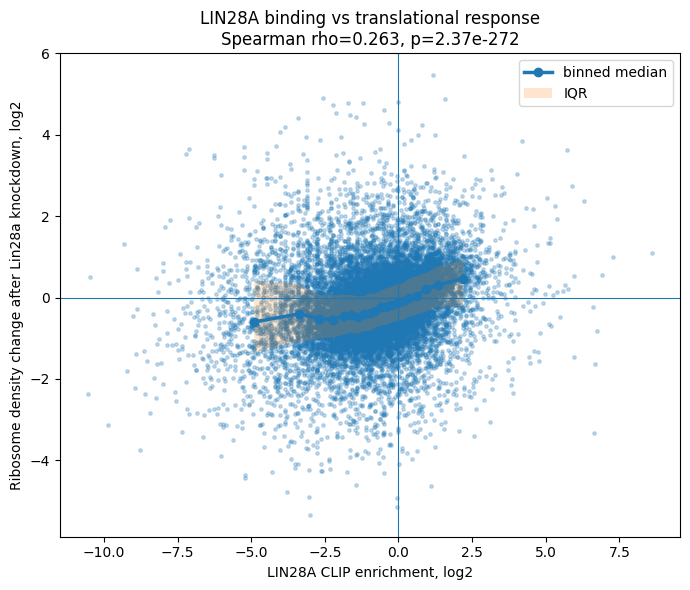

Spearman rho = 0.2633, p = 2.367e-272, n = 17314


In [7]:
def savefig(name):
    path = FIGDIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches='tight')
    print('saved:', path)

plot_df = analysis_f[['clip_log2','rden_log2']].replace([np.inf, -np.inf], np.nan).dropna().copy()
plot_df['bin'] = pd.qcut(plot_df['clip_log2'], q=20, duplicates='drop')
binned = plot_df.groupby('bin', observed=True).agg(
    x_mid=('clip_log2','median'),
    y_med=('rden_log2','median'),
    y_q25=('rden_log2', lambda x: np.quantile(x, 0.25)),
    y_q75=('rden_log2', lambda x: np.quantile(x, 0.75)),
    n=('rden_log2','size')
).reset_index(drop=True)

rho, rho_p = spearmanr(plot_df['clip_log2'], plot_df['rden_log2'])

plt.figure(figsize=(7,6))
plt.scatter(plot_df['clip_log2'], plot_df['rden_log2'], s=6, alpha=0.25)
plt.plot(binned['x_mid'], binned['y_med'], linewidth=2.5, marker='o', label='binned median')
plt.fill_between(binned['x_mid'], binned['y_q25'], binned['y_q75'], alpha=0.2, label='IQR')
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel('LIN28A CLIP enrichment, log2')
plt.ylabel('Ribosome density change after Lin28a knockdown, log2')
plt.title(f'LIN28A binding vs translational response\nSpearman rho={rho:.3f}, p={rho_p:.2e}')
plt.legend()
savefig('fig1_clip_vs_rden_scatter_binned.png')
plt.show()

print(f'Spearman rho = {rho:.4f}, p = {rho_p:.3e}, n = {len(plot_df)}')


## 7. Bootstrap correlation CI와 RNA abundance 변화 비교

논문에서는 LIN28A 결합이 mRNA abundance 변화보다는 ribosome occupancy 변화와 더 관련된다고 해석합니다. 여기서는 `clip_log2`와 `rden_log2`, `rna_change_log2`의 상관을 나란히 비교합니다.


In [9]:
def bootstrap_spearman(x, y, n_boot=1000, seed=2026):
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    n = len(x)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        vals.append(spearmanr(x[idx], y[idx]).statistic)
    vals = np.array(vals)
    return {
        'rho': spearmanr(x, y).statistic,
        'pvalue': spearmanr(x, y).pvalue,
        'ci_low': np.quantile(vals, 0.025),
        'ci_high': np.quantile(vals, 0.975),
        'n': n,
    }

corr_rden = bootstrap_spearman(analysis_f['clip_log2'], analysis_f['rden_log2'])
corr_rna = bootstrap_spearman(analysis_f['clip_log2'], analysis_f['rna_change_log2'])

corr_table = pd.DataFrame([
    {'comparison':'CLIP vs ribosome_density_change', **corr_rden},
    {'comparison':'CLIP vs RNA_abundance_change', **corr_rna},
])
corr_table.to_csv(RESULTDIR / 'correlation_bootstrap_summary.csv', index=False)
display(corr_table)
print('saved:', RESULTDIR / 'correlation_bootstrap_summary.csv')


,comparison,rho,pvalue,ci_low,ci_high,n
0,CLIP vs ribosome_density_change,0.263251,2.367398e-272,0.248243,0.278750,17314
1,CLIP vs RNA_abundance_change,-0.149489,4.424366e-87,-0.165611,-0.134146,17314


saved: /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/results/correlation_bootstrap_summary.csv


## 8. Strong binder vs weak binder 비교 + permutation test

LIN28A 결합 상위 5% 유전자의 ribosome density 변화가 하위 50%보다 큰지 비교합니다.


,strong_n,weak_n,strong_median_rden_log2,weak_median_rden_log2,median_difference,mannwhitney_u_pvalue,permutation_pvalue,cliffs_delta
0,866,8657,0.461285,-0.449018,0.910303,7.797927e-102,0.0002,0.440889


/tmp/ipykernel_6882/3026221664.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


saved: /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/figures/fig2_rden_by_binding_group_boxplot.png


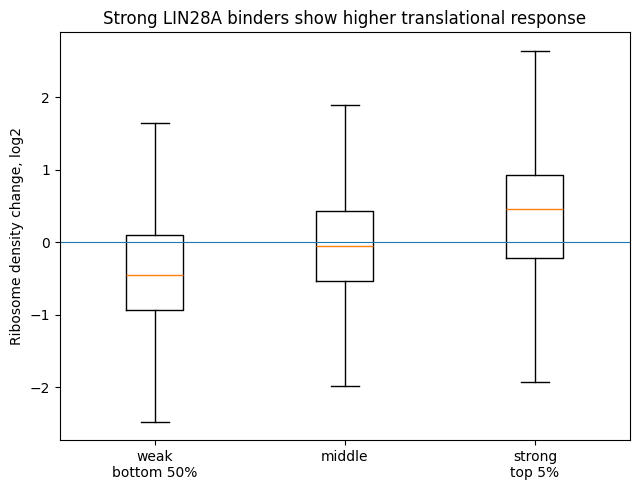

In [10]:
def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    # 표본이 매우 클 때도 과도하게 느려지지 않도록 rank 기반 근사
    combined = pd.Series(np.concatenate([x, y]))
    ranks = combined.rank(method='average').values
    nx = len(x)
    ny = len(y)
    rx = ranks[:nx].sum()
    u = rx - nx * (nx + 1) / 2
    return (2 * u) / (nx * ny) - 1

def permutation_median_diff(x, y, n_perm=5000, seed=2026):
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    obs = np.median(x) - np.median(y)
    pooled = np.concatenate([x, y])
    nx = len(x)
    ge = 0
    for _ in range(n_perm):
        rng.shuffle(pooled)
        stat = np.median(pooled[:nx]) - np.median(pooled[nx:])
        if abs(stat) >= abs(obs):
            ge += 1
    return obs, (ge + 1) / (n_perm + 1)

q95 = analysis_f['clip_log2'].quantile(0.95)
q50 = analysis_f['clip_log2'].quantile(0.50)
group_df = analysis_f.copy()
group_df['binding_group'] = 'middle'
group_df.loc[group_df['clip_log2'] >= q95, 'binding_group'] = 'strong_top5pct'
group_df.loc[group_df['clip_log2'] <= q50, 'binding_group'] = 'weak_bottom50pct'

strong = group_df.loc[group_df['binding_group']=='strong_top5pct', 'rden_log2'].dropna()
weak = group_df.loc[group_df['binding_group']=='weak_bottom50pct', 'rden_log2'].dropna()

mw = mannwhitneyu(strong, weak, alternative='two-sided')
med_diff, perm_p = permutation_median_diff(strong, weak)
cd = cliffs_delta(strong, weak)

group_stats = pd.DataFrame([{
    'strong_n': len(strong), 'weak_n': len(weak),
    'strong_median_rden_log2': np.median(strong),
    'weak_median_rden_log2': np.median(weak),
    'median_difference': med_diff,
    'mannwhitney_u_pvalue': mw.pvalue,
    'permutation_pvalue': perm_p,
    'cliffs_delta': cd,
}])
group_stats.to_csv(RESULTDIR / 'strong_vs_weak_binding_test.csv', index=False)
display(group_stats)

plt.figure(figsize=(6.5,5))
labels = ['weak\nbottom 50%', 'middle', 'strong\ntop 5%']
data = [
    group_df.loc[group_df['binding_group']=='weak_bottom50pct', 'rden_log2'].dropna(),
    group_df.loc[group_df['binding_group']=='middle', 'rden_log2'].dropna(),
    group_df.loc[group_df['binding_group']=='strong_top5pct', 'rden_log2'].dropna(),
]
plt.boxplot(data, labels=labels, showfliers=False)
plt.axhline(0, linewidth=0.8)
plt.ylabel('Ribosome density change, log2')
plt.title('Strong LIN28A binders show higher translational response')
savefig('fig2_rden_by_binding_group_boxplot.png')
plt.show()


## 9. Threshold sensitivity analysis

Top 1%, 5%, 10%, 20% 기준을 바꿔도 같은 방향의 결과가 나오는지 확인합니다.


,top_fraction,threshold_clip_log2,strong_n,weak_n,strong_median_rden_log2,weak_median_rden_log2,median_difference,mannwhitney_pvalue
0,0.01,2.887954,174,8657,0.328706,-0.449018,0.777724,3.572181e-17
1,0.05,1.669825,866,8657,0.461285,-0.449018,0.910303,7.797927e-102
2,0.10,1.116668,1732,8657,0.386937,-0.449018,0.835955,1.248682e-177
3,0.20,0.477755,3463,8657,0.252213,-0.449018,0.701231,2.147704e-240


saved: /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/figures/fig3_threshold_sensitivity.png


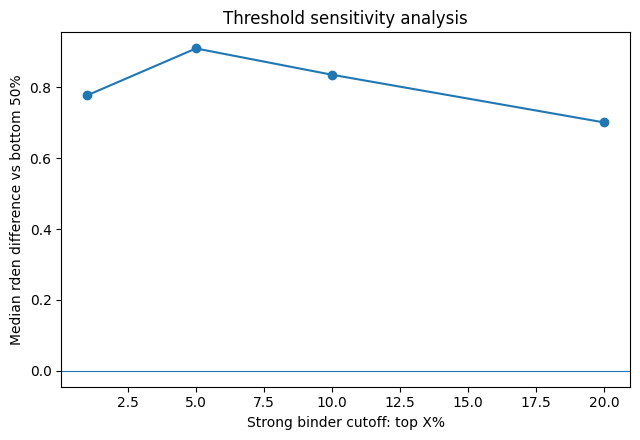

In [11]:
rows = []
for top_frac in [0.01, 0.05, 0.10, 0.20]:
    threshold = analysis_f['clip_log2'].quantile(1 - top_frac)
    strong_i = analysis_f.loc[analysis_f['clip_log2'] >= threshold, 'rden_log2'].dropna()
    weak_i = analysis_f.loc[analysis_f['clip_log2'] <= analysis_f['clip_log2'].quantile(0.50), 'rden_log2'].dropna()
    mw_i = mannwhitneyu(strong_i, weak_i, alternative='two-sided')
    rows.append({
        'top_fraction': top_frac,
        'threshold_clip_log2': threshold,
        'strong_n': len(strong_i),
        'weak_n': len(weak_i),
        'strong_median_rden_log2': np.median(strong_i),
        'weak_median_rden_log2': np.median(weak_i),
        'median_difference': np.median(strong_i) - np.median(weak_i),
        'mannwhitney_pvalue': mw_i.pvalue,
    })
threshold_table = pd.DataFrame(rows)
threshold_table.to_csv(RESULTDIR / 'threshold_sensitivity_analysis.csv', index=False)
display(threshold_table)

plt.figure(figsize=(6.5,4.5))
plt.plot(threshold_table['top_fraction']*100, threshold_table['median_difference'], marker='o')
plt.axhline(0, linewidth=0.8)
plt.xlabel('Strong binder cutoff: top X%')
plt.ylabel('Median rden difference vs bottom 50%')
plt.title('Threshold sensitivity analysis')
savefig('fig3_threshold_sensitivity.png')
plt.show()


## 10. ER/membrane/secretory annotation과 direct target 후보 ranking

논문의 ER-associated translation 결론과 연결하기 위해 mouse localization annotation을 붙입니다. 다운로드가 실패하면 이 section은 자동으로 건너뛰고, count 기반 후보 table만 생성합니다.


In [12]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

local_candidates = [PROJECT_DIR / 'mouselocalization-20210507.txt', DATAPACK_DIR / 'mouselocalization-20210507.txt' if DATAPACK_DIR else None, Path.cwd() / 'mouselocalization-20210507.txt']
local_candidates = [p for p in local_candidates if p is not None]
LOCAL_PATH = next((p for p in local_candidates if p.exists()), None)

if LOCAL_PATH is None:
    try:
        url = 'https://hyeshik.qbio.io/binfo/mouselocalization-20210507.txt'
        mouselocal = pd.read_csv(url, sep='\t')
        LOCAL_PATH = PROJECT_DIR / 'mouselocalization-20210507.txt'
        mouselocal.to_csv(LOCAL_PATH, sep='\t', index=False)
        print('Downloaded localization annotation:', LOCAL_PATH)
    except Exception as e:
        print('Localization annotation 다운로드 실패. 이 부분은 annotation 없이 진행합니다:', e)
        mouselocal = None
else:
    mouselocal = pd.read_csv(LOCAL_PATH, sep='\t')
    print('Loaded localization annotation:', LOCAL_PATH)

candidate = analysis_f.copy()

if mouselocal is not None:
    print('localization columns:', list(mouselocal.columns))
    # gene_id column 자동 탐지
    gid_col = 'gene_id' if 'gene_id' in mouselocal.columns else mouselocal.columns[0]
    type_col = 'type' if 'type' in mouselocal.columns else None
    mouselocal['gene_id_short'] = mouselocal[gid_col].astype(str).str.replace(r'\.\d+$', '', regex=True)
    use_cols = ['gene_id_short'] + ([type_col] if type_col else [])
    annot = mouselocal[use_cols].drop_duplicates('gene_id_short')
    candidate = candidate.merge(annot, on='gene_id_short', how='left')
    if type_col:
        candidate = candidate.rename(columns={type_col: 'localization_type'})
    else:
        candidate['localization_type'] = 'unknown'
    loc_text = candidate['localization_type'].fillna('').astype(str).str.lower()
    candidate['is_er_membrane_secretory'] = loc_text.str.contains('er|endoplasmic|membrane|secret|golgi|lumen|signal')
else:
    candidate['localization_type'] = 'annotation_missing'
    candidate['is_er_membrane_secretory'] = False

# direct target 후보 기준: CLIP 상위 10%이면서 rden_log2 > 0
clip_top10 = candidate['clip_log2'].quantile(0.90)
candidate['is_strong_binder_top10'] = candidate['clip_log2'] >= clip_top10
candidate['is_translation_up'] = candidate['rden_log2'] > 0
candidate['candidate_direct_target'] = candidate['is_strong_binder_top10'] & candidate['is_translation_up']

# ranking score: CLIP, rden은 높을수록, RNA abundance change 절댓값은 작을수록 가산
for col in ['clip_log2','rden_log2']:
    mu = candidate[col].mean()
    sd = candidate[col].std(ddof=0)
    candidate[col + '_z'] = (candidate[col] - mu) / sd if sd > 0 else 0
candidate['rna_change_abs_penalty'] = candidate['rna_change_log2'].abs()
candidate['priority_score'] = candidate['clip_log2_z'] + candidate['rden_log2_z'] - 0.25*candidate['rna_change_abs_penalty'] + 0.5*candidate['is_er_membrane_secretory'].astype(int)

candidate_ranked = candidate.sort_values(['candidate_direct_target','priority_score'], ascending=[False, False]).copy()
cols_to_show = ['Geneid','gene_id_short','clip_log2','rden_log2','rna_change_log2','mean_rna_cpm','mean_rpf_cpm','localization_type','is_er_membrane_secretory','candidate_direct_target','priority_score']
candidate_ranked[cols_to_show].to_csv(RESULTDIR / 'lin28a_candidate_direct_targets_ranked.csv', index=False)
print('saved:', RESULTDIR / 'lin28a_candidate_direct_targets_ranked.csv')
display(candidate_ranked[cols_to_show].head(30))

# annotation 기반 통계
if candidate['is_er_membrane_secretory'].any():
    er = candidate.loc[candidate['is_er_membrane_secretory'], 'rden_log2'].dropna()
    other = candidate.loc[~candidate['is_er_membrane_secretory'], 'rden_log2'].dropna()
    er_mw = mannwhitneyu(er, other, alternative='two-sided')
    # direct target enrichment in ER/membrane/secretory group
    table = pd.crosstab(candidate['is_er_membrane_secretory'], candidate['candidate_direct_target'])
    # fisher table shape 보정
    a = int(table.loc[True, True]) if True in table.index and True in table.columns else 0
    b = int(table.loc[True, False]) if True in table.index and False in table.columns else 0
    c = int(table.loc[False, True]) if False in table.index and True in table.columns else 0
    d = int(table.loc[False, False]) if False in table.index and False in table.columns else 0
    odds, fisher_p = fisher_exact([[a,b],[c,d]])
    loc_stats = pd.DataFrame([{
        'er_group_n': len(er),
        'other_group_n': len(other),
        'er_median_rden_log2': np.median(er),
        'other_median_rden_log2': np.median(other),
        'mannwhitney_pvalue_rden': er_mw.pvalue,
        'fisher_oddsratio_direct_target_enrichment': odds,
        'fisher_pvalue_direct_target_enrichment': fisher_p,
    }])
    loc_stats.to_csv(RESULTDIR / 'er_membrane_secretory_statistics.csv', index=False)
    display(loc_stats)

    plt.figure(figsize=(6.5,5))
    plt.boxplot([other, er], labels=['other', 'ER/membrane/secretory'], showfliers=False)
    plt.axhline(0, linewidth=0.8)
    plt.ylabel('Ribosome density change, log2')
    plt.title('Translational response by localization group')
    savefig('fig4_rden_by_localization_boxplot.png')
    plt.show()
else:
    print('ER/membrane/secretory annotation이 없어 localization 통계는 생략했습니다.')


Localization annotation 다운로드 실패. 이 부분은 annotation 없이 진행합니다: <urlopen error [Errno 104] Connection reset by peer>
saved: /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/results/lin28a_candidate_direct_targets_ranked.csv


,Geneid,gene_id_short,clip_log2,rden_log2,rna_change_log2,mean_rna_cpm,mean_rpf_cpm,localization_type,is_er_membrane_secretory,candidate_direct_target,priority_score
15194,ENSMUSG00000119520.1,ENSMUSG00000119520,5.710221,3.625281,-2.684315,1.986952,7.157967,annotation_missing,False,True,7.049398
55335,ENSMUSG00000064349.1,ENSMUSG00000064349,8.599970,1.105272,-0.685461,5.580937,64.370536,annotation_missing,False,True,6.629871
15195,ENSMUSG00000119132.1,ENSMUSG00000119132,4.187708,3.833897,-2.779869,0.961463,12.304579,annotation_missing,False,True,6.360428
52272,ENSMUSG00000085066.3,ENSMUSG00000085066,6.299469,2.361704,-1.756744,0.552565,2.462717,annotation_missing,False,True,6.323824
38088,ENSMUSG00000052565.8,ENSMUSG00000052565,5.879380,2.743650,-3.120898,2.458456,766.469661,annotation_missing,False,True,6.132447
20589,ENSMUSG00000077711.3,ENSMUSG00000077711,1.160740,5.462319,-3.941178,1.247799,0.093509,annotation_missing,False,True,5.994359
55347,ENSMUSG00000064361.1,ENSMUSG00000064361,7.279784,1.007382,-0.531807,0.869862,9.631482,annotation_missing,False,True,5.805254
21970,ENSMUSG00000030510.12,ENSMUSG00000030510,1.568480,4.876146,-3.355005,0.500007,0.093509,annotation_missing,False,True,5.774351
55324,ENSMUSG00000064338.1,ENSMUSG00000064338,5.049576,2.432601,-1.680069,2.220238,1203.700714,annotation_missing,False,True,5.693918
55330,ENSMUSG00000064344.1,ENSMUSG00000064344,5.310513,2.246998,-1.731106,2.443957,770.755884,annotation_missing,False,True,5.641237


ER/membrane/secretory annotation이 없어 localization 통계는 생략했습니다.


## 11. 선택 업그레이드 A: RPF 5′ end start-codon profile

2주차 과제의 RPF start-codon profile을 다시 생성합니다. BAM, GTF, samtools, bedtools가 있을 때만 실행됩니다. 실패해도 핵심 direct-target 분석은 유지됩니다.


In [13]:
def ensure_tools_for_bam():
    missing = [cmd for cmd in ['samtools','bedtools'] if which(cmd) is None]
    if missing:
        print('Missing tools:', missing, '설치를 시도합니다.')
        if which('apt-get'):
            run('apt-get update -qq && apt-get install -y -qq samtools bedtools', check=False)
    return all(which(cmd) for cmd in ['samtools','bedtools'])

rpf_bam = bam_paths.get('RPF-siLuc.bam') if 'bam_paths' in globals() else None
can_start_profile = (rpf_bam is not None and Path(rpf_bam).exists() and GTF_PATH is not None and ensure_tools_for_bam())

if not can_start_profile:
    print('RPF start-codon profile 생략: BAM/GTF/samtools/bedtools 중 일부가 없습니다.')
else:
    gtf_for_shell = str(GTF_PATH)
    # bedtools는 gzipped GTF를 직접 못 읽는 경우가 있어 압축 해제본을 준비합니다.
    if str(GTF_PATH).endswith('.gz'):
        gtf_plain = TMPDIR / 'gencode.gtf'
        if not gtf_plain.exists():
            run(f'gzip -cd {GTF_PATH} > {gtf_plain}', check=True)
    else:
        gtf_plain = Path(GTF_PATH)

    start_gtf = TMPDIR / 'gencode-start.gtf'
    exon_gtf = TMPDIR / 'gencode-plusexon.gtf'
    exon_bed = TMPDIR / 'gencode-exons-containing-startcodon.bed'
    filt_bam = TMPDIR / 'filtered-RPF-siLuc.bam'
    fivep_bed = TMPDIR / 'fivepcounts-RPF-siLuc.bed'
    fivep_intersect = TMPDIR / 'fivepcounts-filtered-RPF-siLuc.txt'

    run(f"awk '$3 == \"start_codon\" && $7 == \"+\" {{ print $0; }}' {gtf_plain} > {start_gtf}", check=True)
    run(f"awk '$3 == \"exon\" && $7 == \"+\" {{ print $0; }}' {gtf_plain} > {exon_gtf}", check=True)
    run(f"bedtools intersect -a {start_gtf} -b {exon_gtf} -wa -wb | awk -F'\\t' -v OFS='\\t' '$9 == $18 {{ print $10, $13-1, $14, $18, $4-1, $16; }}' | sort -k1,1 -k2,3n -k4,4 > {exon_bed}", check=True)
    run(f"(samtools view -H {rpf_bam}; samtools view -F20 {rpf_bam} | awk '{{ if (length($10) >= 25) print $0; }}') | samtools view -b -o {filt_bam}", check=True)
    run(f"bedtools genomecov -ibam {filt_bam} -bg -5 > {fivep_bed}", check=True)
    run(f"bedtools intersect -a {fivep_bed} -b {exon_bed} -wa -wb -nonamecheck > {fivep_intersect}", check=True)

    from collections import Counter
    distance_counts = Counter()
    chunksize = 200000
    for chunk in pd.read_csv(fivep_intersect, sep='\t', header=None, chunksize=chunksize):
        relative_distances = chunk[1] - chunk[8]
        counts = chunk[3]
        for dist, count in zip(relative_distances, counts):
            if -100 <= dist <= 100:
                distance_counts[int(dist)] += float(count)

    x_range = np.arange(-50, 51)
    y_values = [distance_counts[int(x)] for x in x_range]
    profile_df = pd.DataFrame({'distance_from_start_codon': x_range, 'fiveprime_count': y_values})
    profile_df.to_csv(RESULTDIR / 'rpf_5prime_start_codon_profile.csv', index=False)

    plt.figure(figsize=(10,4.5))
    plt.bar(x_range, y_values, width=0.8)
    plt.axvline(0, linestyle='--', linewidth=1)
    plt.xlabel('Relative position from start codon (nt)')
    plt.ylabel("RPF 5' end count")
    plt.title("RPF-siLuc 5' end profile around start codons")
    savefig('fig5_rpf_5prime_start_codon_profile.png')
    plt.show()


Missing tools: ['samtools', 'bedtools'] 설치를 시도합니다.

$ apt-get update -qq && apt-get install -y -qq samtools bedtools

$ awk '$3 == "start_codon" && $7 == "+" { print $0; }' /content/drive/MyDrive/binfo1-work/gencode.gtf > /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/tmp/gencode-start.gtf

$ awk '$3 == "exon" && $7 == "+" { print $0; }' /content/drive/MyDrive/binfo1-work/gencode.gtf > /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/tmp/gencode-plusexon.gtf

$ bedtools intersect -a /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/tmp/gencode-start.gtf -b /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/tmp/gencode-plusexon.gtf -wa -wb | awk -F'\t' -v OFS='\t' '$9 == $18 { print $10, $13-1, $14, $18, $4-1, $16; }' | sort -k1,1 -k2,3n -k4,4 > /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/tmp/gencode-exons-containing-startcodon.bed

$ (samtools view -H /content/drive/MyDrive/binfo1-work/RPF-siLuc.bam; samtools view -F20 /content/drive/MyDrive/binfo1-work/RPF-siLu

KeyboardInterrupt: 

## 12. 선택 업그레이드 B: let-7 precursor 주변 CLIP mismatch entropy

3주차 과제에서 좌표를 직접 입력했던 부분을 개선하여, GTF에서 `Mirlet7g`, `Mirlet7d`, `Mirlet7f-1`의 좌표를 자동으로 찾고, 각 위치의 Shannon entropy bedGraph를 만듭니다.


,gene_name,chrom,start,end,strand
0,Mirlet7g,chr9,106056019,106056146,+
1,Mirlet7d,chr13,48689468,48689610,-
2,Mirlet7f-1,chr13,48691285,48691413,-



$ samtools view -b -o /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/tmp/CLIP-Mirlet7g.bam /content/drive/MyDrive/binfo1-work/CLIP-35L33G.bam chr9:106056019-106056146

$ samtools mpileup /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/tmp/CLIP-Mirlet7g.bam > /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/tmp/CLIP-Mirlet7g.pileup
saved: /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/results/CLIP-Mirlet7g.entropy.bedgraph

$ samtools view -b -o /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/tmp/CLIP-Mirlet7d.bam /content/drive/MyDrive/binfo1-work/CLIP-35L33G.bam chr13:48689468-48689610

$ samtools mpileup /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/tmp/CLIP-Mirlet7d.bam > /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/tmp/CLIP-Mirlet7d.pileup
saved: /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/results/CLIP-Mirlet7d.entropy.bedgraph

$ samtools view -b -o /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/tmp/CLIP-Mirlet7f-1.bam /cont

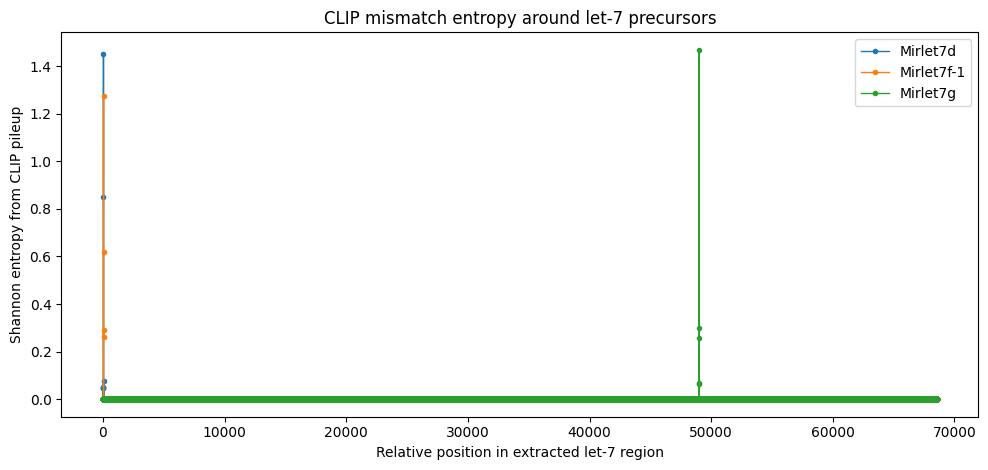

In [14]:
def parse_attributes(attr):
    d = {}
    for part in attr.strip().split(';'):
        part = part.strip()
        if not part:
            continue
        if ' ' in part:
            key, val = part.split(' ', 1)
            d[key] = val.strip().strip('"')
    return d

def open_maybe_gzip(path):
    path = Path(path)
    if str(path).endswith('.gz'):
        return gzip.open(path, 'rt')
    return open(path, 'rt')

def find_gene_regions_from_gtf(gtf_path, gene_names, padding=20):
    targets = set(gene_names)
    rows = []
    with open_maybe_gzip(gtf_path) as fh:
        for line in fh:
            if line.startswith('#'):
                continue
            fields = line.rstrip('\n').split('\t')
            if len(fields) < 9:
                continue
            chrom, source, feature, start, end, score, strand, frame, attr = fields
            attrs = parse_attributes(attr)
            gname = attrs.get('gene_name') or attrs.get('gene_id') or ''
            if gname in targets and feature in {'gene','transcript','exon'}:
                rows.append({'gene_name': gname, 'chrom': chrom, 'start': int(start), 'end': int(end), 'strand': strand})
    out = []
    for g in gene_names:
        sub = [r for r in rows if r['gene_name'] == g]
        if not sub:
            continue
        chroms = sorted(set(r['chrom'] for r in sub))
        chrom = chroms[0]
        starts = [r['start'] for r in sub if r['chrom']==chrom]
        ends = [r['end'] for r in sub if r['chrom']==chrom]
        strand = sub[0]['strand']
        out.append({'gene_name': g, 'chrom': chrom, 'start': max(1, min(starts)-padding), 'end': max(ends)+padding, 'strand': strand})
    return pd.DataFrame(out)

pileup_cleanup_re = re.compile(r'\^.|\$|[+-][0-9]+[ACGTNacgtn]+|[^ACGTNacgtn.,]')

def pileup_bases_to_entropy(bases, ref_base):
    # mpileup: .와 ,는 reference match이므로 ref base로 바꿉니다.
    if not isinstance(bases, str):
        return 0.0
    s = pileup_cleanup_re.sub('', bases)
    s = s.replace('.', ref_base.upper()).replace(',', ref_base.upper()).upper()
    letters = [ch for ch in s if ch in 'ACGTN']
    if not letters:
        return 0.0
    counts = pd.Series(letters).value_counts()
    p = counts / counts.sum()
    return float(-(p * np.log2(p)).sum())

clip_bam = bam_paths.get('CLIP-35L33G.bam') if 'bam_paths' in globals() else None
can_entropy = (clip_bam is not None and Path(clip_bam).exists() and GTF_PATH is not None and ensure_tools_for_bam())

if not can_entropy:
    print('let-7 entropy 분석 생략: CLIP BAM/GTF/samtools 중 일부가 없습니다.')
else:
    let7_regions = find_gene_regions_from_gtf(GTF_PATH, ['Mirlet7g','Mirlet7d','Mirlet7f-1'], padding=20)
    let7_regions.to_csv(RESULTDIR / 'let7_regions_from_gtf.csv', index=False)
    display(let7_regions)
    entropy_tables = []
    for _, row in let7_regions.iterrows():
        gene = row['gene_name']
        region = f"{row['chrom']}:{row['start']}-{row['end']}"
        out_bam = TMPDIR / f'CLIP-{gene}.bam'
        pileup_path = TMPDIR / f'CLIP-{gene}.pileup'
        bedgraph_path = RESULTDIR / f'CLIP-{gene}.entropy.bedgraph'
        run(f'samtools view -b -o {out_bam} {clip_bam} {region}', check=True)
        run(f'samtools mpileup {out_bam} > {pileup_path}', check=True)
        if pileup_path.stat().st_size == 0:
            print(gene, 'pileup이 비었습니다:', region)
            continue
        pu = pd.read_csv(pileup_path, sep='\t', names=['chrom','pos','ref','count','basereads','quals'])
        pu['shannon_entropy'] = [pileup_bases_to_entropy(b, r) for b, r in zip(pu['basereads'], pu['ref'])]
        bed = pd.DataFrame({'chrom': pu['chrom'], 'start': pu['pos']-1, 'end': pu['pos'], 'value': pu['shannon_entropy']})
        bed.to_csv(bedgraph_path, sep='\t', header=False, index=False)
        pu['gene_name'] = gene
        entropy_tables.append(pu)
        print('saved:', bedgraph_path)

    if entropy_tables:
        entropy_all = pd.concat(entropy_tables, ignore_index=True)
        entropy_all.to_csv(RESULTDIR / 'let7_clip_entropy_all_sites.csv', index=False)
        # 각 gene별 위치를 상대좌표로 그립니다.
        plt.figure(figsize=(10,4.8))
        for gene, sub in entropy_all.groupby('gene_name'):
            sub = sub.sort_values('pos')
            rel = sub['pos'] - sub['pos'].min()
            plt.plot(rel, sub['shannon_entropy'], marker='o', linewidth=1, markersize=3, label=gene)
        plt.xlabel('Relative position in extracted let-7 region')
        plt.ylabel('Shannon entropy from CLIP pileup')
        plt.title('CLIP mismatch entropy around let-7 precursors')
        plt.legend()
        savefig('fig6_let7_clip_entropy_profiles.png')
        plt.show()
    else:
        print('entropy table이 생성되지 않았습니다.')


## 13. 결과 요약 파일 만들기

README나 발표에 바로 쓸 수 있도록 핵심 결과를 `summary.json`과 `summary.txt`로 저장합니다.


In [15]:
summary = {
    'project_title': 'LIN28A direct target prioritization upgrade v3',
    'n_all_genes': int(len(analysis)),
    'n_filtered_genes': int(len(analysis_f)),
    'spearman_clip_vs_rden': corr_rden,
    'spearman_clip_vs_rna_change': corr_rna,
    'strong_vs_weak_binding_test': group_stats.iloc[0].to_dict(),
    'n_candidate_direct_targets': int(candidate['candidate_direct_target'].sum()),
    'output_project_dir': str(PROJECT_DIR),
}
with open(RESULTDIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

summary_lines = [
    '# LIN28A upgrade v3 summary',
    f"filtered genes: {len(analysis_f)} / all genes: {len(analysis)}",
    f"Spearman(CLIP, rden change): rho={corr_rden['rho']:.4f}, p={corr_rden['pvalue']:.3e}, 95% CI=({corr_rden['ci_low']:.4f}, {corr_rden['ci_high']:.4f})",
    f"Spearman(CLIP, RNA change): rho={corr_rna['rho']:.4f}, p={corr_rna['pvalue']:.3e}, 95% CI=({corr_rna['ci_low']:.4f}, {corr_rna['ci_high']:.4f})",
    f"Strong top5 median rden - weak bottom50 median rden: {float(group_stats['median_difference'].iloc[0]):.4f}",
    f"Mann-Whitney p-value: {float(group_stats['mannwhitney_u_pvalue'].iloc[0]):.3e}",
    f"candidate direct targets: {int(candidate['candidate_direct_target'].sum())}",
]
with open(RESULTDIR / 'summary.txt', 'w') as f:
    f.write('\n'.join(summary_lines) + '\n')

print('\n'.join(summary_lines))
print('saved:', RESULTDIR / 'summary.json')
print('saved:', RESULTDIR / 'summary.txt')


# LIN28A upgrade v3 summary
filtered genes: 17314 / all genes: 55359
Spearman(CLIP, rden change): rho=0.2633, p=2.367e-272, 95% CI=(0.2482, 0.2787)
Spearman(CLIP, RNA change): rho=-0.1495, p=4.424e-87, 95% CI=(-0.1656, -0.1341)
Strong top5 median rden - weak bottom50 median rden: 0.9103
Mann-Whitney p-value: 7.798e-102
candidate direct targets: 1166
saved: /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/results/summary.json
saved: /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/results/summary.txt


## 14. 제출 전 checklist

이 셀이 `PASS`를 출력해야 합니다. `FAIL`이 있으면 해당 파일이 생성되지 않은 것입니다.


In [16]:
expected = [
    RESULTDIR / 'lin28a_filtered_gene_metrics.csv',
    RESULTDIR / 'lin28a_candidate_direct_targets_ranked.csv',
    RESULTDIR / 'correlation_bootstrap_summary.csv',
    RESULTDIR / 'strong_vs_weak_binding_test.csv',
    RESULTDIR / 'threshold_sensitivity_analysis.csv',
    RESULTDIR / 'summary.txt',
    FIGDIR / 'fig1_clip_vs_rden_scatter_binned.png',
    FIGDIR / 'fig2_rden_by_binding_group_boxplot.png',
    FIGDIR / 'fig3_threshold_sensitivity.png',
]
missing = [p for p in expected if not p.exists() or p.stat().st_size == 0]
print('Expected required files:')
for p in expected:
    print(('OK   ' if p.exists() and p.stat().st_size > 0 else 'MISS '), p)

if missing:
    print('\nFAIL: 필수 결과 파일이 일부 없습니다. 위 셀의 에러 메시지를 확인하고 다시 Run all 하세요.')
else:
    print('\nPASS: 핵심 결과 파일이 모두 생성되었습니다.')
    print('이제 이 노트북을 저장한 뒤, PROJECT_DIR의 figures/와 results/ 폴더까지 GitHub에 push하세요.')


Expected required files:
OK    /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/results/lin28a_filtered_gene_metrics.csv
OK    /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/results/lin28a_candidate_direct_targets_ranked.csv
OK    /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/results/correlation_bootstrap_summary.csv
OK    /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/results/strong_vs_weak_binding_test.csv
OK    /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/results/threshold_sensitivity_analysis.csv
OK    /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/results/summary.txt
OK    /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/figures/fig1_clip_vs_rden_scatter_binned.png
OK    /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/figures/fig2_rden_by_binding_group_boxplot.png
OK    /content/drive/MyDrive/binfo1-work/LIN28A_upgrade_v3/figures/fig3_threshold_sensitivity.png

PASS: 핵심 결과 파일이 모두 생성되었습니다.
이제 이 노트북을 저장한 뒤, PROJECT_DIR의 figures/와 results